Goal: define which road segments are too risky in wet conditions and remove them from a copy of the graph.

In [12]:
import networkx as nx
from config import get_default_graph, NODE_POS
from utils import draw_graph

G = get_default_graph()

nx.describe(G)

Number of nodes                : 11
Number of edges                : 13
Directed                       : False
Multigraph                     : False
Tree                           : False
Bipartite                      : False
Average degree (min, max)      : 2.36 (2, 4)
Number of connected components : 1


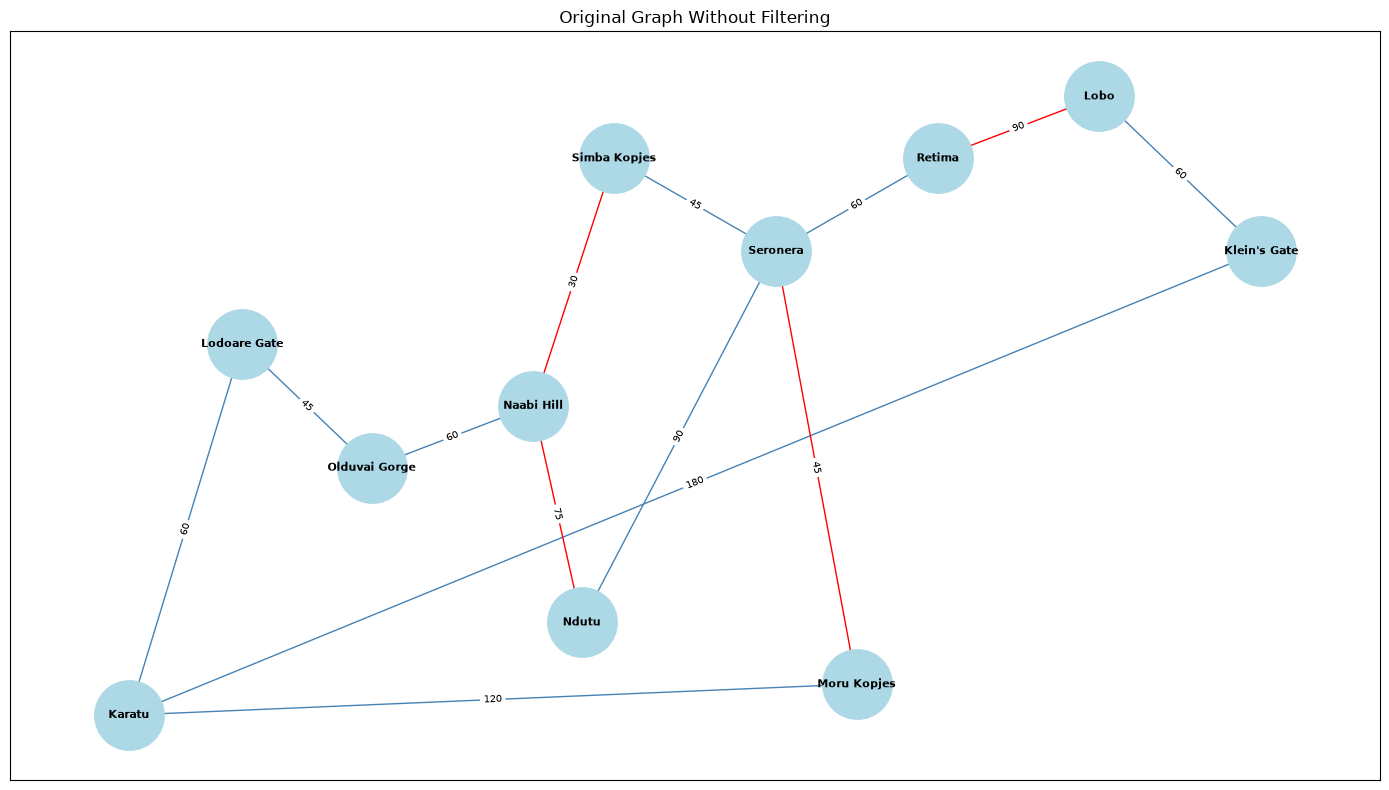

In [13]:
original_edge_labels = {(u, v): data['road'].travel_time for u, v, data in G.edges(data=True)}

draw_graph(G, NODE_POS, original_edge_labels, 'Original Graph Without Filtering')

In [14]:
def apply_mud_filter(graph: nx.Graph, risk_threshold="high"):
    filtered_graph = graph.copy()
    edges_to_remove = [(u, v) for u, v, data in filtered_graph.edges(data=True) if data['road'].risk == risk_threshold]
    filtered_graph.remove_edges_from(edges_to_remove)
    return filtered_graph

In [15]:
G_filtered = apply_mud_filter(G)

print(nx.describe(G_filtered))


Number of nodes                : 11
Number of edges                : 9
Directed                       : False
Multigraph                     : False
Tree                           : False
Bipartite                      : True
Average degree (min, max)      : 1.64 (1, 3)
Number of connected components : 2
None


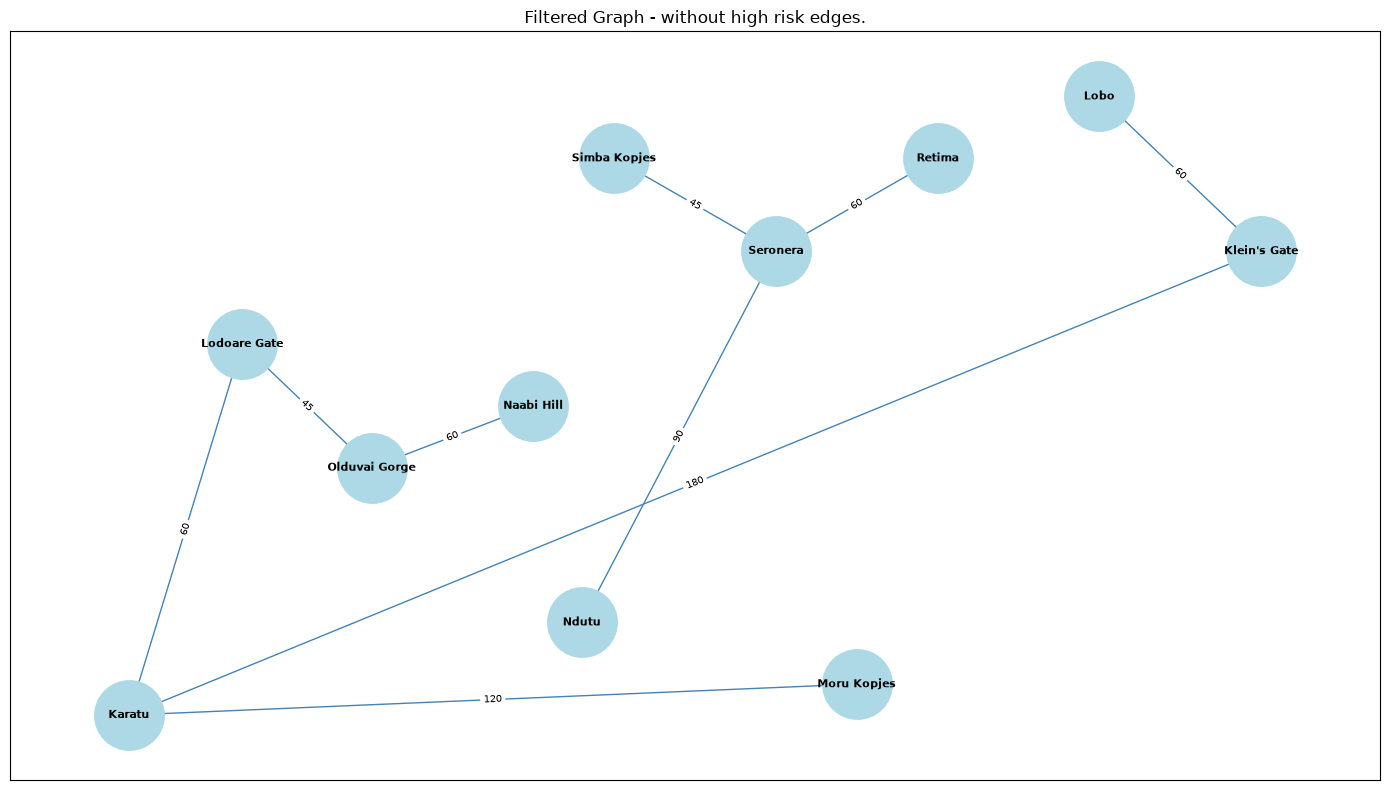

In [16]:
edge_labels = {(u, v): data['road'].travel_time for u, v, data in G_filtered.edges(data=True)}

draw_graph(G_filtered, NODE_POS, edge_labels, "Filtered Graph - without high risk edges.")

## Notes
- Instead of saying "this road is forbidden," we could say "this road is allowed but expensive."
    - Edge weight: cost = f_1(travel_time) + f_2(road_conditions)
    - Dijkstra still works, basically we just want to minimize the total cost instead of total_time.
    - Instead of a hard exclusion we could just have the soft cost adoption.
    - We need to find a way to describe 'f'.


## Comparing side by side - The scenario where we want to remove specific edges

In [17]:
WET_SEASON_EXCLUDED_EDGES = [
    ("Seronera", "Moru Kopjes"),   # Black cotton soil, floods after rain
    ("Retima",   "Lobo"),          # Western Corridor — highest risk segment
    ("Lobo",     "Klein's Gate"),  # Same risk zone as above
]

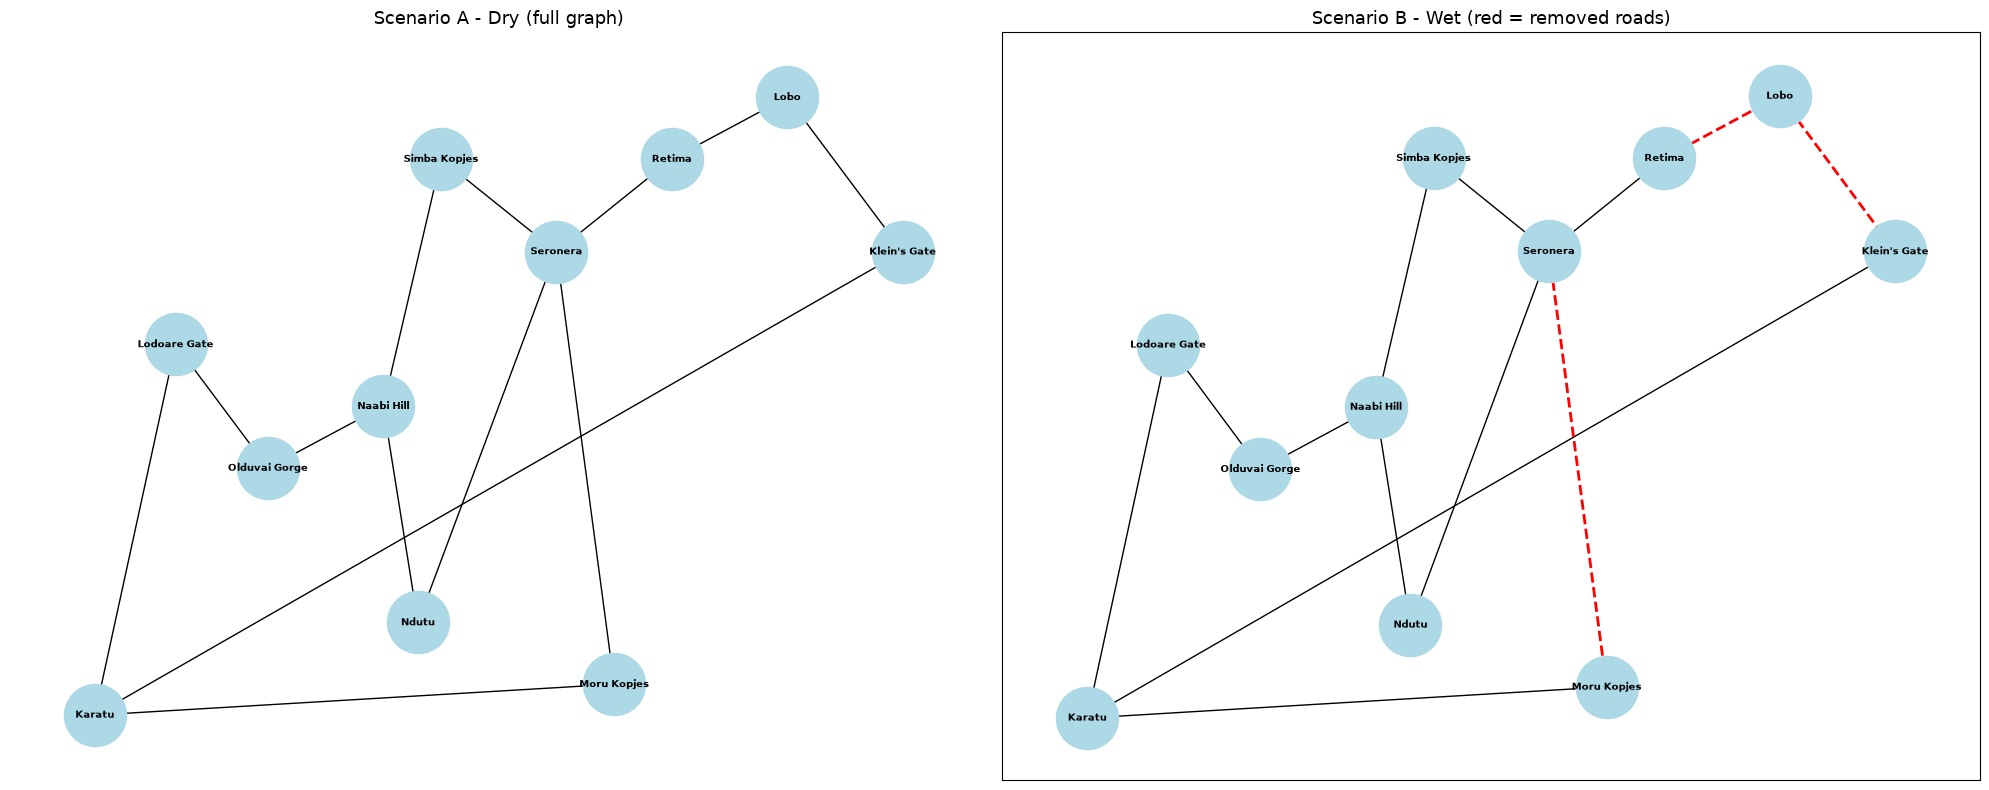

In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Scenario A — full graph
nx.draw(G, NODE_POS, ax=ax1,
        with_labels=True, node_color='lightblue',
        node_size=2000, font_size=7, font_weight='bold')
ax1.set_title("Scenario A - Dry (full graph)", fontsize=13)

# Scenario B — filtered graph
# Highlight removed edges in red on the original layout
removed = [(u, v) for u, v in WET_SEASON_EXCLUDED_EDGES if G.has_edge(u, v)]
remaining = [(u, v) for u, v in G.edges() if (u, v) not in removed
             and (v, u) not in removed]

nx.draw_networkx_nodes(G, NODE_POS, ax=ax2, node_color='lightblue', node_size=2000)
nx.draw_networkx_labels(G, NODE_POS, ax=ax2, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G, NODE_POS, edgelist=remaining, ax=ax2, edge_color='black')
nx.draw_networkx_edges(G, NODE_POS, edgelist=removed, ax=ax2,
                       edge_color='red', style='dashed', width=2)
ax2.set_title("Scenario B - Wet (red = removed roads)", fontsize=13)

plt.tight_layout()
plt.show()